**About this Dataset**

**Context**

Term deposits are a major source of income for a bank. A term deposit is a cash investment held at a financial institution. Your money is invested for an agreed rate of interest over a fixed amount of time, or term. The bank has various outreach plans to sell term deposits to their customers such as email marketing, advertisements, telephonic marketing, and digital marketing.

Telephonic marketing campaigns still remain one of the most effective way to reach out to people. However, they require huge investment as large call centers are hired to actually execute these campaigns. Hence, it is crucial to identify the customers most likely to convert beforehand so that they can be specifically targeted via call.

The data is related to direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe to a term deposit (variable y).

**Content**

The data is related to the direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to access if the product (bank term deposit) would be ('yes') or not ('no') subscribed by the customer or not. The data folder contains two datasets:-

- train.csv: 45,211 rows and 18 columns ordered by date (from May 2008 to November 2010)
- test.csv: 4521 rows and 18 columns with 10% of the examples (4521), randomly selected from train.csv

Detailed Column Descriptions
bank client data:

1. age (numeric)
2. job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
"blue-collar","self-employed","retired","technician","services")
3. marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)
4. education (categorical: "unknown","secondary","primary","tertiary")
5. default: has credit in default? (binary: "yes","no")
6. balance: average yearly balance, in euros (numeric)
7. housing: has housing loan? (binary: "yes","no")
8. loan: has personal loan? (binary: "yes","no")

**related with the last contact of the current campaign:**

9. contact: contact communication type (categorical: "unknown","telephone","cellular")
10. day: last contact day of the month (numeric)
11. month: last contact month of year (categorical: "jan", "feb", "mar", …, "nov", "dec")
12. duration: last contact duration, in seconds (numeric)
**other attributes:**

13. campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
14. pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)
15. previous: number of contacts performed before this campaign and for this client (numeric)
16. poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

Output variable (desired target):

17. y - has the client subscribed a term deposit? (binary: "yes","no")

Missing Attribute Values: None

# EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df_train=pd.read_csv('/content/bank_train.csv',sep=";")

In [ ]:
df_test=pd.read_csv('/content/bank_test.csv',sep=";")

In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
df_test.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no


In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4521 entries, 0 to 4520
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        4521 non-null   int64 
 1   job        4521 non-null   object
 2   marital    4521 non-null   object
 3   education  4521 non-null   object
 4   default    4521 non-null   object
 5   balance    4521 non-null   int64 
 6   housing    4521 non-null   object
 7   loan       4521 non-null   object
 8   contact    4521 non-null   object
 9   day        4521 non-null   int64 
 10  month      4521 non-null   object
 11  duration   4521 non-null   int64 
 12  campaign   4521 non-null   int64 
 13  pdays      4521 non-null   int64 
 14  previous   4521 non-null   int64 
 15  poutcome   4521 non-null   object
 16  y          4521 non-null   object
dtypes: int64(7), object(10)
memory usage: 600.6+ KB


In [ ]:
df_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [ ]:
df_train.describe(include=['object','category'])

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


In [ ]:
df_test.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [ ]:
df_test.describe(include=['object','category'])

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,4521,4521,4521,4521,4521,4521,4521,4521,4521,4521
unique,12,3,4,2,2,2,3,12,4,2
top,management,married,secondary,no,yes,no,cellular,may,unknown,no
freq,969,2797,2306,4445,2559,3830,2896,1398,3705,4000


In [ ]:
df_train.shape

(45211, 17)

In [ ]:
df_test.shape

(4521, 17)

In [ ]:
# data analysis and preprocessor for both train and test then will pass data to it
# train split then test

Target Column:**y**

CLASSIFICATION PROBLEM-supervised and binary

**Problem Statement**:Predict whether a customer will subscribe to a term deposit (yes or no).

poutcome = Previous Outcome

What happened in the previous marketing campaign with that customer.

- success → Customer subscribed previously
- failure → Customer did not subscribe ❌
- unknown → No previous data / never contacted
- other → Other outcomes

In [ ]:
# dividing into numerical and categorical columns
num_col=df_train.select_dtypes(include=['int64','float64']).columns
num_col

Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

In [ ]:
cat_col=df_train.select_dtypes(include=['object','category']).columns
cat_col

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

In [ ]:
df_train.duplicated().sum()

np.int64(0)

In [ ]:
df_test.duplicated().sum()

np.int64(0)

In [ ]:
# null value checking
df_train.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
df_test.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


**VISUALIZATIONS**

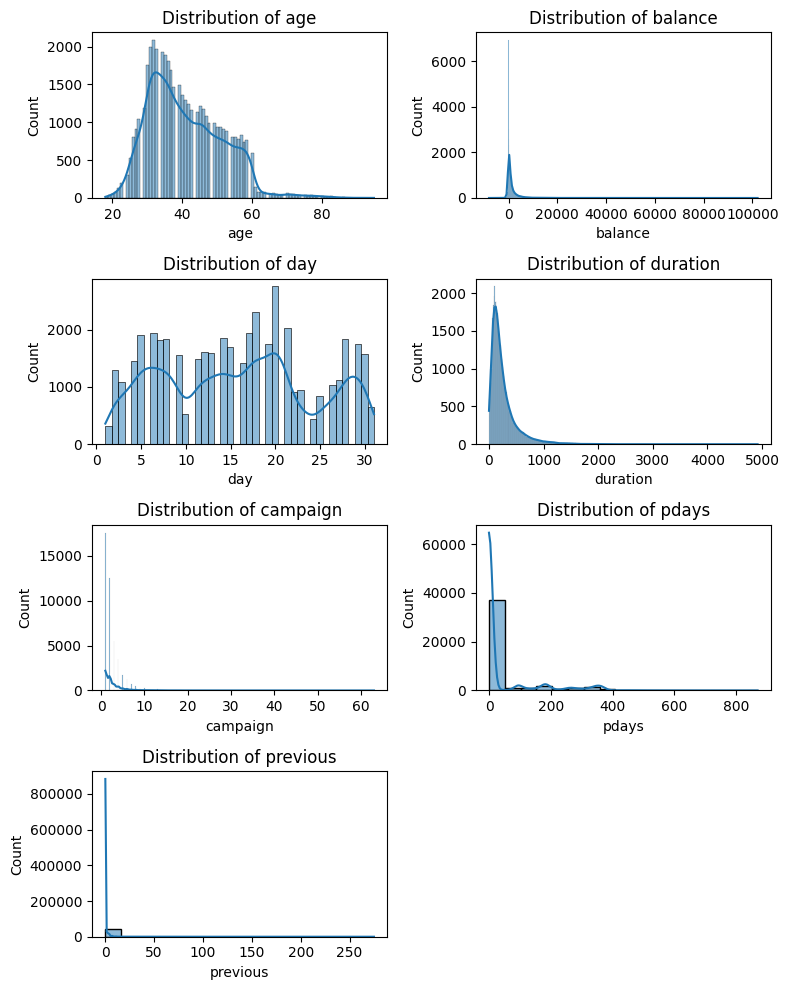

In [ ]:
plt.figure(figsize=(8,10))
for i,col in enumerate(num_col,1):
  plt.subplot(4,2,i)
  sns.histplot(df_train[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

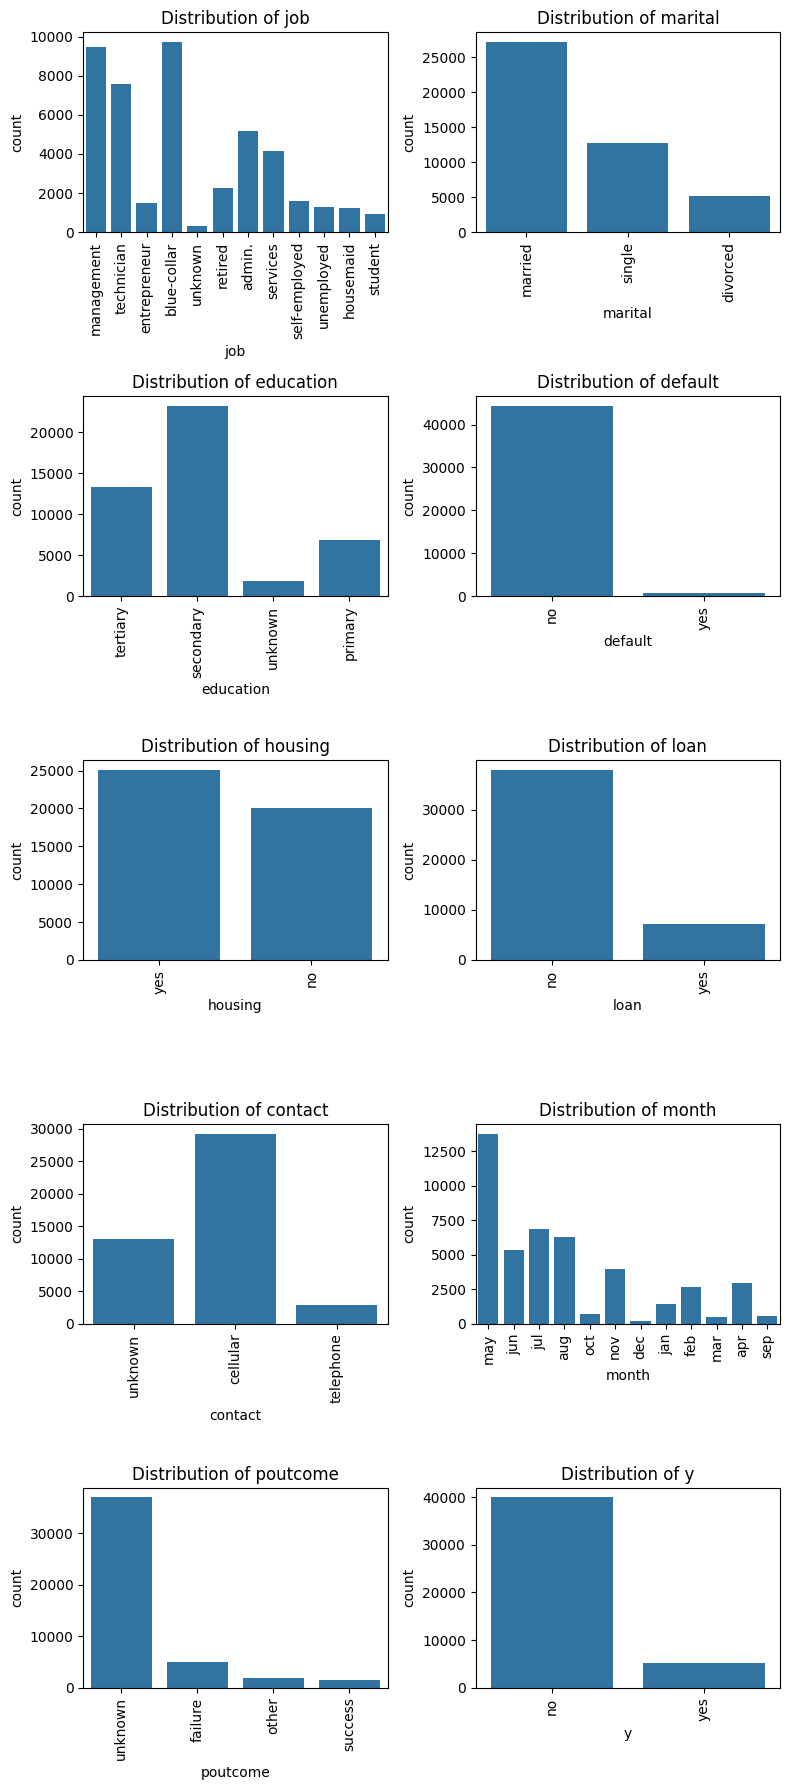

In [ ]:
plt.figure(figsize=(8,18))
for i,col in enumerate(cat_col,1):
  plt.subplot(5,2,i)
  sns.countplot(x=col, data=df_train)
  plt.xticks(rotation=90)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

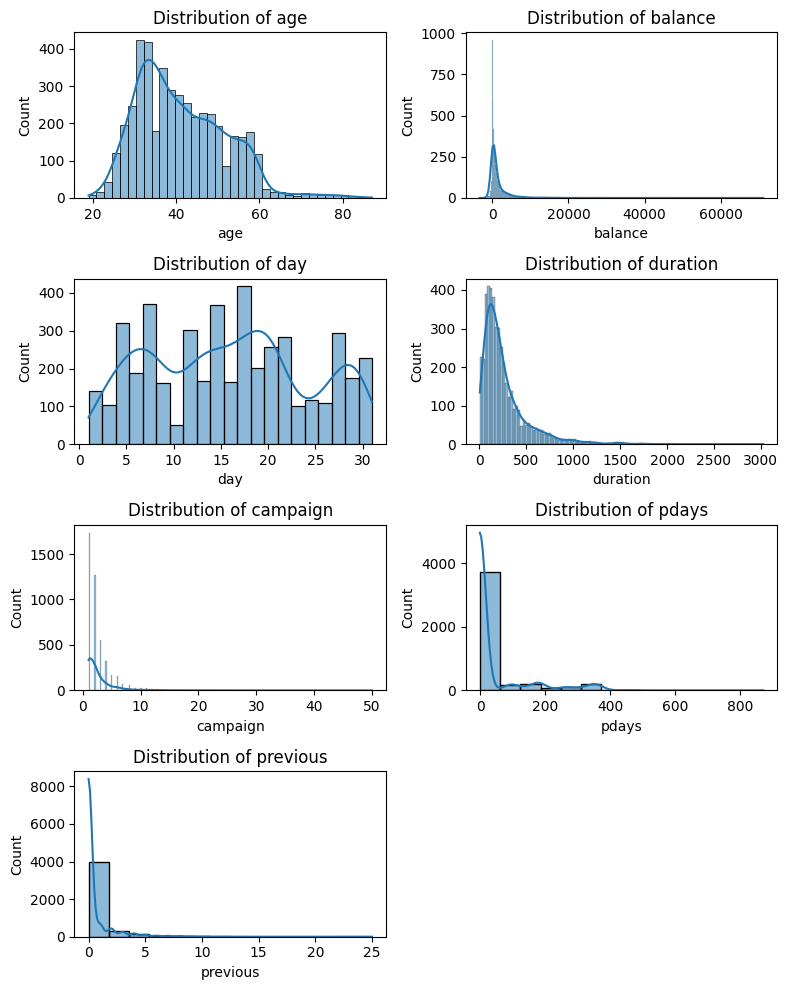

In [ ]:
plt.figure(figsize=(8,10))
for i,col in enumerate(num_col,1):
  plt.subplot(4,2,i)
  sns.histplot(df_test[col],kde=True)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

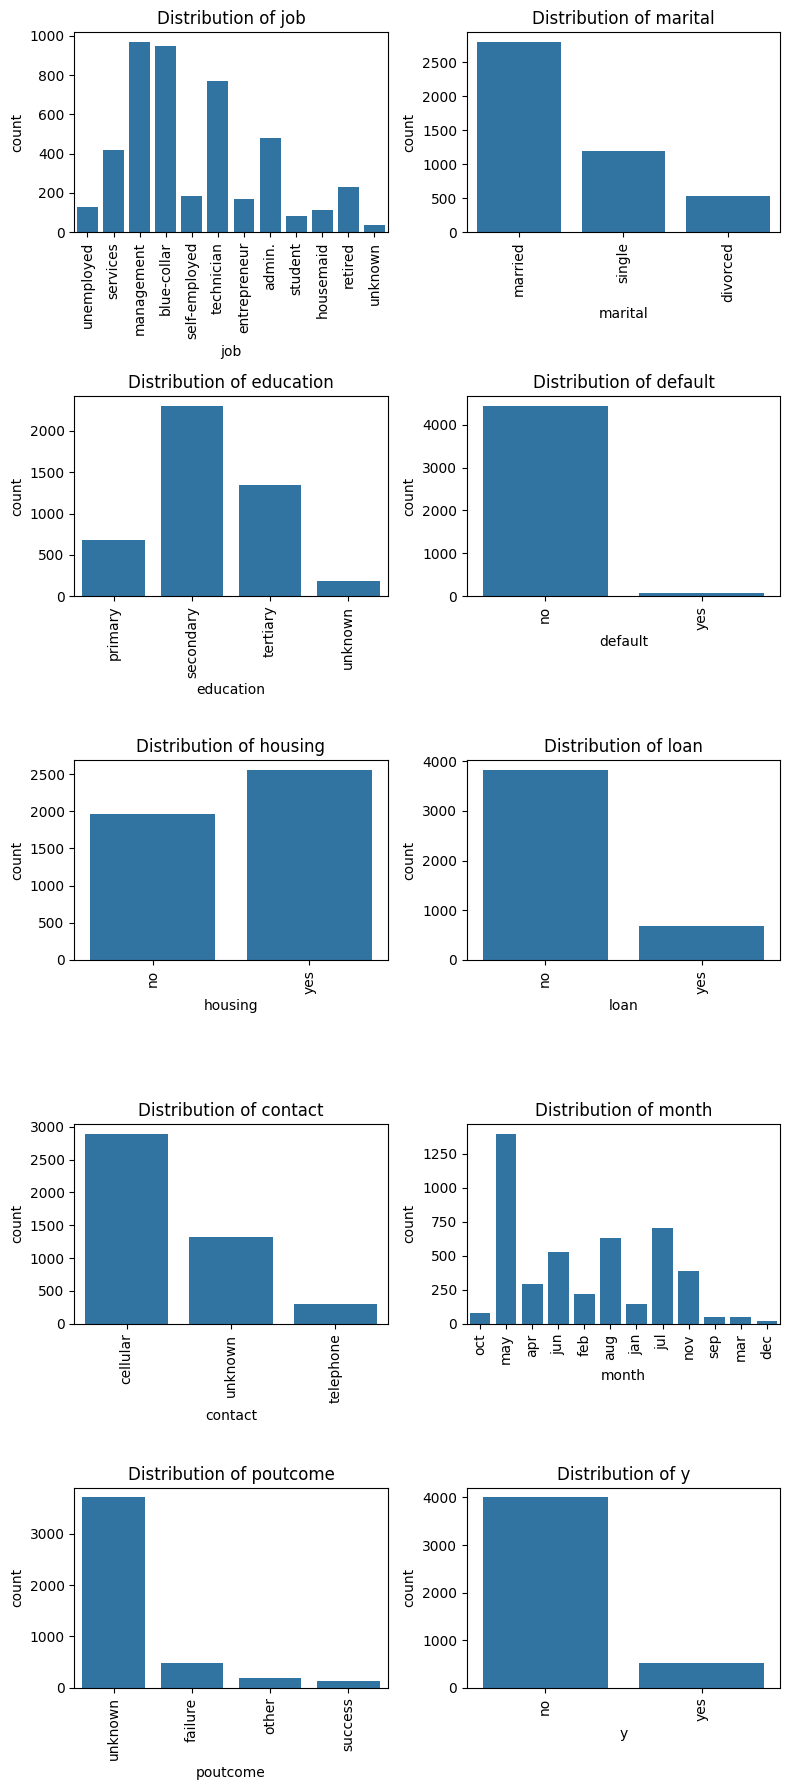

In [ ]:
plt.figure(figsize=(8,18))
for i,col in enumerate(cat_col,1):
  plt.subplot(5,2,i)
  sns.countplot(x=col, data=df_test)
  plt.xticks(rotation=90)
  plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [ ]:
cat_cols=cat_col.drop('y')
cat_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

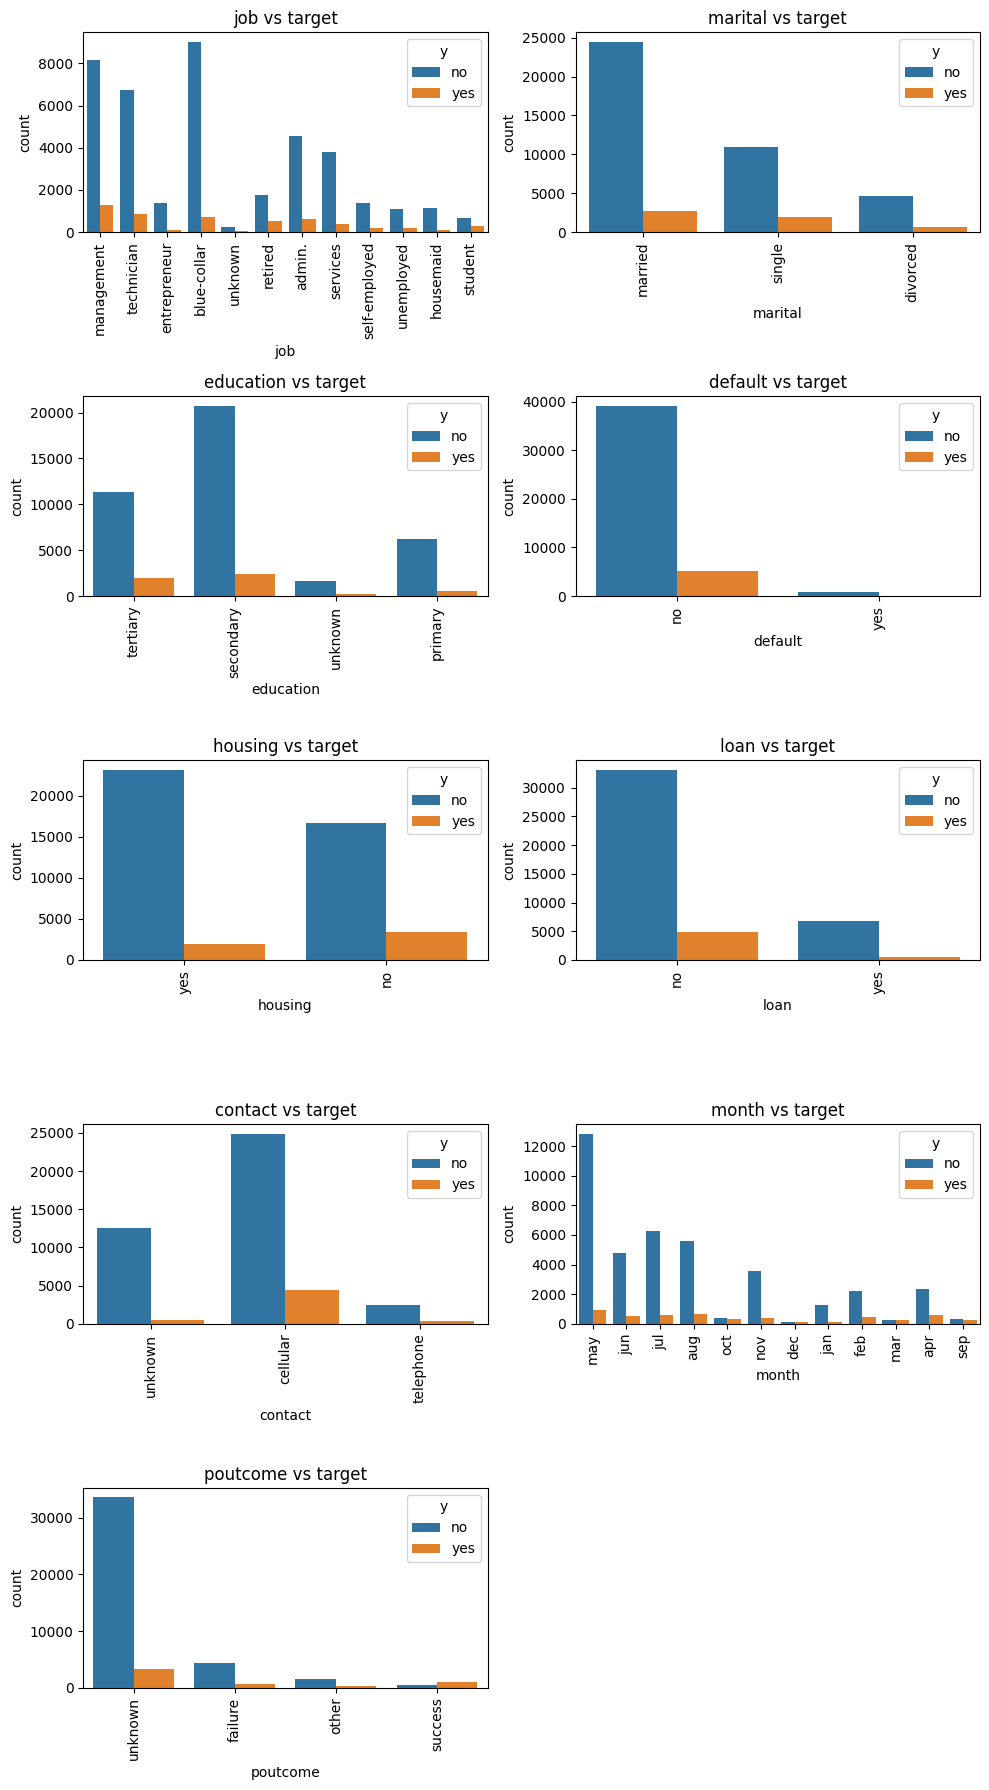

In [ ]:
plt.figure(figsize=(10,18))
for i,col in enumerate(cat_cols,1):
  plt.subplot(5,2,i)
  sns.countplot(x=col,hue='y',data=df_train)
  plt.xticks(rotation=90)
  plt.title(f'{col} vs target')

plt.tight_layout()
plt.show()

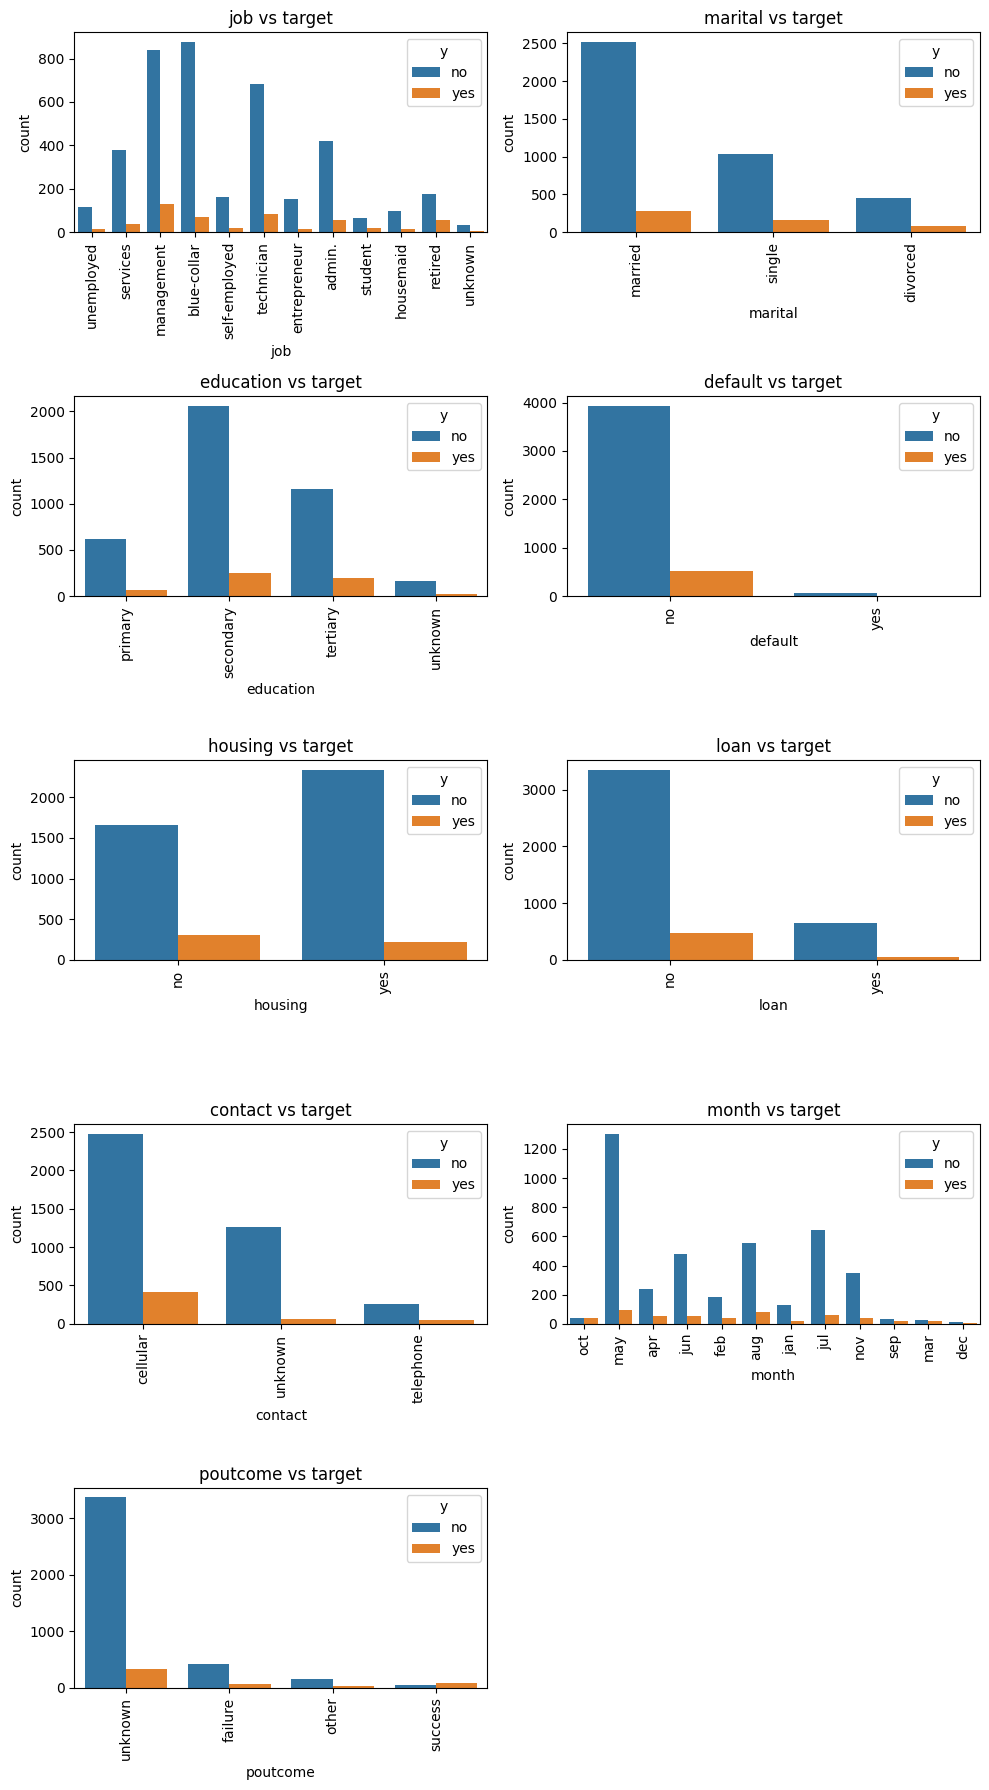

In [ ]:
plt.figure(figsize=(10,18))
for i,col in enumerate(cat_cols,1):
  plt.subplot(5,2,i)
  sns.countplot(x=col,hue='y',data=df_test)
  plt.xticks(rotation=90)
  plt.title(f'{col} vs target')

plt.tight_layout()
plt.show()

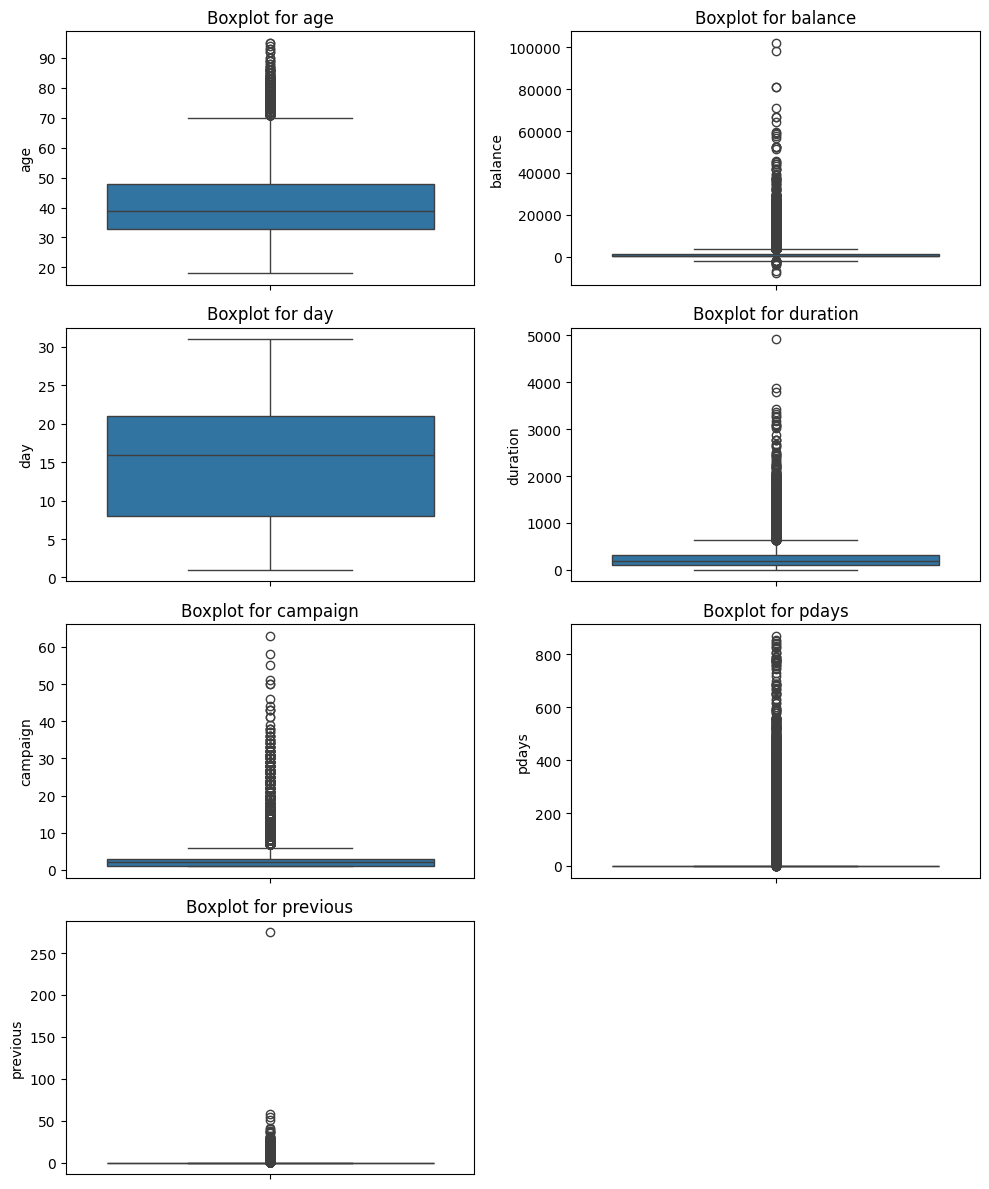

In [ ]:
# outlier checking
plt.figure(figsize=(10,12))
for i,col in enumerate(num_col,1):
  plt.subplot(4,2,i)
  sns.boxplot(df_train[col])
  plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

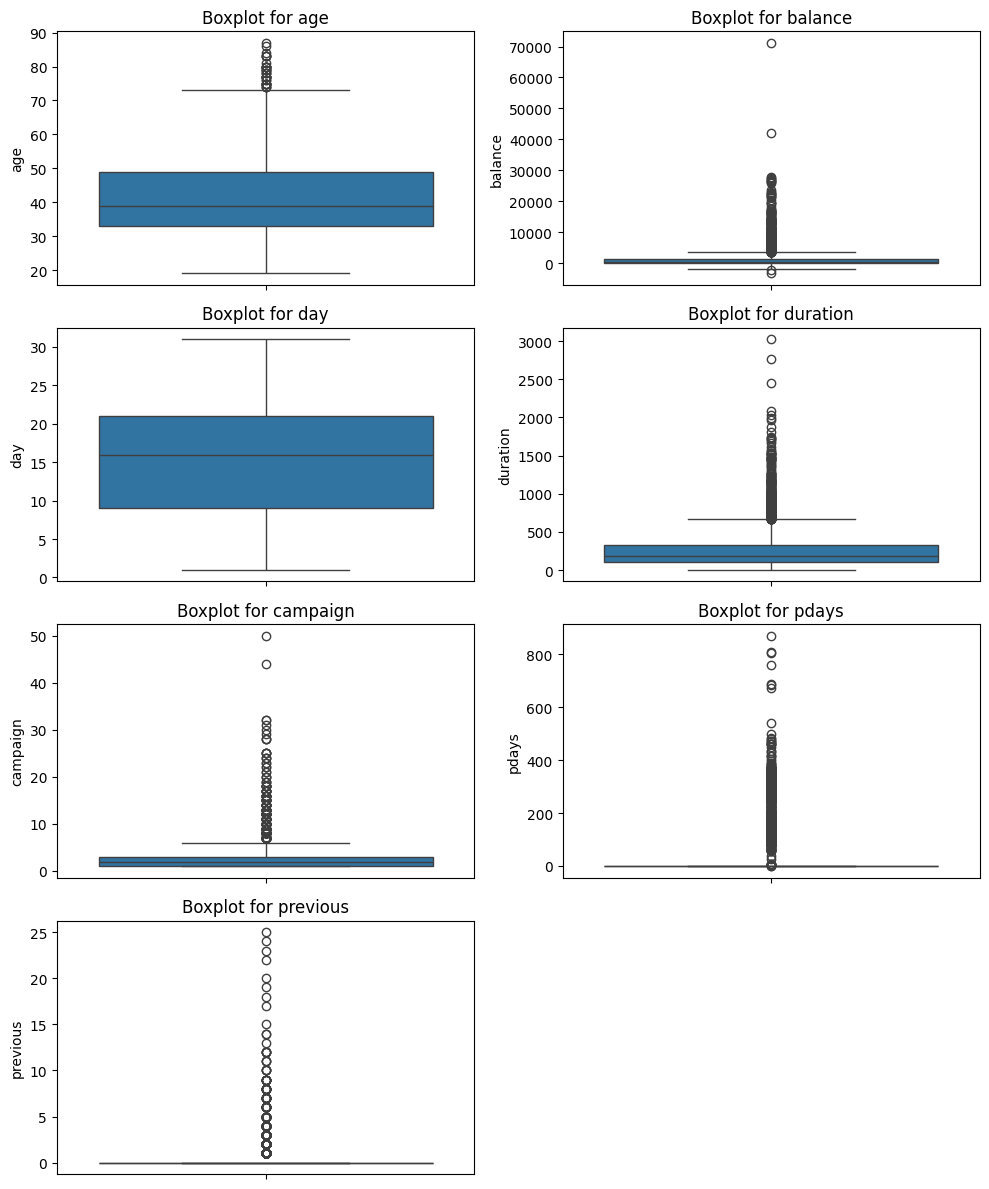

In [ ]:
# outlier checking
plt.figure(figsize=(10,12))
for i,col in enumerate(num_col,1):
  plt.subplot(4,2,i)
  sns.boxplot(df_test[col])
  plt.title(f'Boxplot for {col}')

plt.tight_layout()
plt.show()

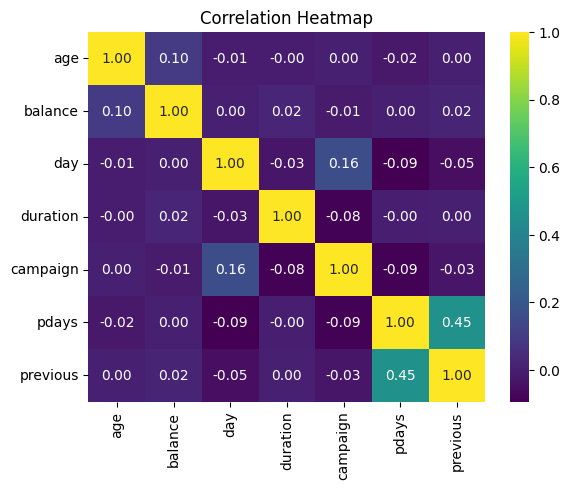

In [ ]:
corr=df_train[num_col].corr()
sns.heatmap(corr,annot=True, fmt='0.2f',cmap = 'viridis')
plt.title('Correlation Heatmap')
plt.show()

# Feature Engineering

In [ ]:
# Label encoding target
df_train['y'] = df_train['y'].map({'no':0, 'yes':1})
df_test['y'] = df_test['y'].map({'no':0, 'yes':1})

In [ ]:
# mapping binary cols
df_train['housing'] = df_train['housing'].map({'no':0, 'yes':1})
df_test['housing'] = df_test['housing'].map({'no':0, 'yes':1})
df_train['loan'] = df_train['loan'].map({'no':0, 'yes':1})
df_test['loan'] = df_test['loan'].map({'no':0, 'yes':1})
df_train['default'] = df_train['default'].map({'no':0, 'yes':1})
df_test['default'] = df_test['default'].map({'no':0, 'yes':1})

In [ ]:
df_train['age_group'] = pd.cut(
    df_train['age'],
    bins=[0,25,35,45,60,100],
    labels=['young','adult','mid','senior','old']
)

In [ ]:
df_train['balance_category'] = pd.cut(
    df_train['balance'],
    bins=[-10000,0,1000,5000,150000],
    labels=['negative','low','medium','high']
)

In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,age_group,balance_category
0,58,management,married,tertiary,0,2143,1,0,unknown,5,may,261,1,-1,0,unknown,0,senior,medium
1,44,technician,single,secondary,0,29,1,0,unknown,5,may,151,1,-1,0,unknown,0,mid,low
2,33,entrepreneur,married,secondary,0,2,1,1,unknown,5,may,76,1,-1,0,unknown,0,adult,low
3,47,blue-collar,married,unknown,0,1506,1,0,unknown,5,may,92,1,-1,0,unknown,0,senior,medium
4,33,unknown,single,unknown,0,1,0,0,unknown,5,may,198,1,-1,0,unknown,0,adult,low


In [ ]:
df_test['age_group'] = pd.cut(
    df_test['age'],
    bins=[0,25,35,45,60,100],
    labels=['young','adult','mid','senior','old']
)

In [ ]:
df_test['balance_category'] = pd.cut(
    df_test['balance'],
    bins=[-10000,0,1000,5000,150000],
    labels=['negative','low','medium','high']
)

In [ ]:
df_train['pdays_contacted'] = (
    df_train['pdays'] != -1
).astype(int)

df_test['pdays_contacted'] = (
    df_test['pdays'] != -1
).astype(int)

df_train['pdays'] = df_train['pdays'].replace(-1, 0)
df_test['pdays'] = df_test['pdays'].replace(-1, 0)

In [ ]:
df_train['contacted_before'] = (
    df_train['previous'] > 0
).astype(int)

df_test['contacted_before'] = (
    df_test['previous'] > 0
).astype(int)

Age,pdays and previous creating new features corresponding to it hence not handling ouliers as age is genuine and the other two are count based so capping or log transforming looses its actual meaning.

Balance will log transform as highly right skewed and genuine with large extreme values and even negative values.

Duration causes data leakage because it is only known after the call is completed. Since our goal is to predict customer response before making the call, duration should not be used in the model.Long call → yes
Short call → no which is not realistic

Campaign capping as its count based so natural skeweness possible.It has small range with many small values so those if log transformed it compresses differences which makes it hard to interpret.

In [ ]:
df_train=df_train.drop('duration',axis=1,errors='ignore')
df_test=df_test.drop('duration',axis=1,errors='ignore')

In [ ]:
df_train['balance'] = (
    np.sign(df_train['balance']) *
    np.log1p(abs(df_train['balance']))
)

df_test['balance'] = (
    np.sign(df_test['balance']) *
    np.log1p(abs(df_test['balance']))
)

In [ ]:
def cap_outliers(series):
  Q1=series.quantile(0.25)
  Q3=series.quantile(0.75)
  IQR=Q3-Q1

  # define bounds
  lower_bound=Q1-1.5*IQR # little lower than box's line but not outside the end line
  upper_bound=Q3+1.5*IQR

  #cap the values
  series=np.where(series>upper_bound,upper_bound,series) # replace with value of upperbound # (,,series) tells take each row
  series=np.where(series<lower_bound,lower_bound,series)
  return series

In [ ]:
df_train['campaign']=cap_outliers(df_train['campaign'])
df_test['campaign']=cap_outliers(df_test['campaign'])

In [ ]:
df_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,pdays,previous,poutcome,y,age_group,balance_category,pdays_contacted,contacted_before
0,58,management,married,tertiary,0,7.670429,1,0,unknown,5,may,1.0,0,0,unknown,0,senior,medium,0,0
1,44,technician,single,secondary,0,3.401197,1,0,unknown,5,may,1.0,0,0,unknown,0,mid,low,0,0
2,33,entrepreneur,married,secondary,0,1.098612,1,1,unknown,5,may,1.0,0,0,unknown,0,adult,low,0,0
3,47,blue-collar,married,unknown,0,7.317876,1,0,unknown,5,may,1.0,0,0,unknown,0,senior,medium,0,0
4,33,unknown,single,unknown,0,0.693147,0,0,unknown,5,may,1.0,0,0,unknown,0,adult,low,0,0


# Preprocessing

In [ ]:
X_train= df_train.drop('y',axis=1)
y_train= df_train['y']
X_test= df_test.drop('y',axis=1)
y_test= df_test['y']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder

pass_cols=['default','housing','loan','pdays_contacted','contacted_before'] # binary

numerical_cols=['age','balance','campaign','day','pdays','previous']

categorical_cols=['contact','marital','job','month','poutcome']

ordinal_cols=['age_group','balance_category','education'] #natural order

preprocessor= ColumnTransformer(transformers=[
    ("binary","passthrough",pass_cols),
    ("num",StandardScaler(),numerical_cols),
    ("cat",OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_cols),
    ("ord",OrdinalEncoder(categories=[['young','adult','mid','senior','old'],['negative','low','medium','high'],['unknown','primary','secondary','tertiary']]),ordinal_cols)
])

In [ ]:
df_train['y'].value_counts()

,count
y,
0,39922
1,5289


In [ ]:
df_test['y'].value_counts()

,count
y,
0,4000
1,521


# Model Selection and Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight='balanced'))
])

pipe_knn = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier())
])

pipe_svr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", SVC(class_weight='balanced'))
])

pipe_dt = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=5,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_rf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_gb = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier())
])

pipe_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(scale_pos_weight=7.7,random_state=42))
])

In [ ]:
pipe_lr.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)
pipe_svr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_gb.fit(X_train, y_train)
pipe_xgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('binary', 'passthrough',
                                                  ['default', 'housing', 'loan',
                                                   'pdays_contacted',
                                                   'contacted_before']),
                                                 ('num', StandardScaler(),
                                                  ['age', 'balance', 'campaign',
                                                   'day', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['contact', 'marital', 'job',
                                                   'month', 'poutcome']),
                                                 ('ord',
                                                  Or...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [ ]:
y_pred_lr = pipe_lr.predict(X_test)
y_pred_knn = pipe_knn.predict(X_test)
y_pred_svc = pipe_svr.predict(X_test)
y_pred_dt = pipe_dt.predict(X_test)
y_pred_rf = pipe_rf.predict(X_test)
y_pred_gb = pipe_gb.predict(X_test)
y_pred_xgb = pipe_xgb.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

a_lr=accuracy_score(y_test,y_pred_lr)
a_knn=accuracy_score(y_test,y_pred_knn)
a_svc=accuracy_score(y_test,y_pred_svc)
a_dtc=accuracy_score(y_test,y_pred_dt)
a_rfc=accuracy_score(y_test,y_pred_rf)
a_gb=accuracy_score(y_test,y_pred_gb)
a_xgb=accuracy_score(y_test,y_pred_xgb)

p_lr=precision_score(y_test,y_pred_lr)
p_knn=precision_score(y_test,y_pred_knn)
p_svc=precision_score(y_test,y_pred_svc)
p_dtc=precision_score(y_test,y_pred_dt)
p_rfc=precision_score(y_test,y_pred_rf)
p_gb=precision_score(y_test,y_pred_gb)
p_xgb=precision_score(y_test,y_pred_xgb)

r_lr=recall_score(y_test,y_pred_lr)
r_knn=recall_score(y_test,y_pred_knn)
r_svc=recall_score(y_test,y_pred_svc)
r_dtc=recall_score(y_test,y_pred_dt)
r_rfc=recall_score(y_test,y_pred_rf)
r_gb=recall_score(y_test,y_pred_gb)
r_xgb=recall_score(y_test,y_pred_xgb)

f_lr=f1_score(y_test,y_pred_lr)
f_knn=f1_score(y_test,y_pred_knn)
f_svc=f1_score(y_test,y_pred_svc)
f_dtc=f1_score(y_test,y_pred_dt)
f_rfc=f1_score(y_test,y_pred_rf)
f_gb=f1_score(y_test,y_pred_gb)
f_xgb=f1_score(y_test,y_pred_xgb)

roc_lr=roc_auc_score(y_test,y_pred_lr)
roc_knn=roc_auc_score(y_test,y_pred_knn)
roc_svc=roc_auc_score(y_test,y_pred_svc)
roc_dtc=roc_auc_score(y_test,y_pred_dt)
roc_rfc=roc_auc_score(y_test,y_pred_rf)
roc_gb=roc_auc_score(y_test,y_pred_gb)
roc_xgb=roc_auc_score(y_test,y_pred_xgb)

results_df=pd.DataFrame({
    'Model':['Logistic Regression','KNN','SVC','Decision Tree','Random Forest','Gradient Boost','XG Boost'],
    'accuracy_score':[a_lr,a_knn,a_svc,a_dtc,a_rfc,a_gb,a_xgb],
    'precision':[p_lr,p_knn,p_svc,p_dtc,p_rfc,p_gb,p_xgb],
    'recall':[r_lr,r_knn,r_svc,r_dtc,r_rfc,r_gb,r_xgb],
    'f1 score':[f_lr,f_knn,f_svc,f_dtc,f_rfc,f_gb,f_xgb],
    'roc auc':[roc_lr,roc_knn,roc_svc,roc_dtc,roc_rfc,roc_gb,roc_xgb]

})

In [ ]:
results_df

,Model,accuracy_score,precision,recall,f1 score,roc auc
0,Logistic Regression,0.744747,0.241210,0.566219,0.338303,0.667109
1,KNN,0.904446,0.706977,0.291747,0.413043,0.637998
2,SVC,0.819067,0.337349,0.591171,0.429568,0.719960
3,Decision Tree,0.796948,0.279199,0.481766,0.353521,0.659883
4,Random Forest,0.804689,0.307036,0.552783,0.394791,0.695142
5,Gradient Boost,0.895820,0.678571,0.182342,0.287443,0.585546
6,XG Boost,0.870161,0.463736,0.809981,0.589797,0.843990


- XGBoost is the best-performing model, achieving an accuracy score of 0.8702, which indicates that the model correctly predicts whether a customer will subscribe to a term deposit approximately 87% of the time.

- Precision (~0.46) indicates that when the model predicts a customer will subscribe to a term deposit, it is correct about 46% of the time, meaning that some false positive predictions are still present.

- Recall (~0.81) shows that out of all customers who actually subscribed to a term deposit, the model successfully identifies about 81% of them. This is a strong result, as identifying potential subscribers is important for marketing campaigns.

- F1 Score (~0.59) represents a balanced measure between precision and recall, indicating that the model maintains a good trade-off between identifying actual subscribers and avoiding incorrect predictions.

- ROC-AUC Score (~0.84) reflects the model’s ability to distinguish between customers who will subscribe and those who will not. A score close to 0.84 indicates strong discriminative ability, meaning the model performs significantly better than random guessing and can reliably separate the two classes.

No  = 4000
Yes = 521

4000 / 521 ≈ 7.7

Mistakes on "Yes" customers
are 7.7 times more serious
than mistakes on "No" customers

For banking dataset recall is very important as it makes sure there is less FN as we sholud not miss the potential clients who actually will subscribe leading to revenue loss.

In [ ]:
# confusion metrics
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test,y_pred_xgb)

array([[3512,  488],
       [  99,  422]])

In [ ]:
# Get feature names after preprocessing
feature_names = pipe_xgb.named_steps['preprocessor'].get_feature_names_out()

In [ ]:
# Get feature importance from XGB
importances = pipe_xgb.named_steps['model'].feature_importances_

In [ ]:
import pandas as pd

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
38,cat__poutcome_success,0.307699
12,cat__contact_unknown,0.107052
32,cat__month_mar,0.059901
34,cat__month_nov,0.034550
35,cat__month_oct,0.033071
30,cat__month_jul,0.031923
1,binary__housing,0.029568
26,cat__month_aug,0.029496
29,cat__month_jan,0.025546
36,cat__month_sep,0.022640


- The most important feature influencing term deposit subscription is previous campaign outcome (poutcome_success), contributing approximately 30.8% to the model's prediction power. This indicates that customers who previously subscribed to a term deposit are significantly more likely to subscribe again, making prior campaign success a strong predictor of future responses.

- Several month-related features, such as March, October, July, November, and August, also show relatively high importance. This suggests that seasonal trends play a key role in customer subscription behavior, and certain months are more favorable for marketing campaigns.

- The contact method (contact_unknown) and housing loan status (housing) also contribute meaningfully to predictions, indicating that communication channels and customers' financial commitments influence their decision-making behavior.

- Overall, the model highlights that previous customer interaction history, seasonal timing, and financial profile are the key drivers influencing term deposit subscriptions.